Online Retail Dataset

In [1]:
# Import KaggleHub to download the dataset from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("luisrenterialezano/retail-sales-dataset")

print("Path to dataset files:", path)

c:\Users\Alessia_March\Desktop\progetti_github\.progetti\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Alessia_March\.cache\kagglehub\datasets\luisrenterialezano\retail-sales-dataset\versions\1


In [2]:

# Import the required libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)

# Display the first rows and dataset dimensions
print(df.head())
print(df.shape[0], df.shape[1])

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
541909 8


In [ ]:

data=df.copy() # working copy of the original dataset

# Remove the product description column since I do not consider it usefull for product segmentation and clustering
data=data.drop(["Description"], axis=1)


In [5]:

data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"]) #convert to datetime

# Identify rows containing at least one missing value
missing_rows = data[data.isna().any(axis=1)]
print(missing_rows.shape[0])

# Check whether all missing values are in CustomerID
missing_customer_id = data[data["CustomerID"].isna()]

# Verify if the two subsets are identical. If this is true then CustomerID is the only column with missing values
same_missing_rows = missing_rows.equals(missing_customer_id)
print(same_missing_rows)

# Removing the rows with missing values.
validated_data = data[data['CustomerID'].notna()]


135080
True


In [6]:
# Identify return transactions (negative quantities)
returns= validated_data[validated_data["Quantity"]<0]
returns

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...
540449,C581490,23144,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [7]:
clients= validated_data["CustomerID"].unique()# Get unique customers
print(f"Total unique customers: {len(clients)}")

Total unique customers: 4372


In [8]:
# Check if any customer has transactions from multiple countries
country_per_client = validated_data.groupby("CustomerID")["Country"].nunique()
print("Customers with transactions in multiple countries:", (country_per_client == 1).all())

# Display customers who bought from multiple countries
client_multi_country = country_per_client[country_per_client > 1]
print("Multi-country customers:", client_multi_country)
for client in client_multi_country.index:
    country = validated_data[validated_data["CustomerID"] == client]["Country"].unique()
    print(client, country)

Customers with transactions in multiple countries: False
Multi-country customers: CustomerID
12370.0    2
12394.0    2
12417.0    2
12422.0    2
12429.0    2
12431.0    2
12455.0    2
12457.0    2
Name: Country, dtype: int64
12370.0 <StringArray>
['Cyprus', 'Austria']
Length: 2, dtype: str
12394.0 <StringArray>
['Belgium', 'Denmark']
Length: 2, dtype: str
12417.0 <StringArray>
['Belgium', 'Spain']
Length: 2, dtype: str
12422.0 <StringArray>
['Australia', 'Switzerland']
Length: 2, dtype: str
12429.0 <StringArray>
['Denmark', 'Austria']
Length: 2, dtype: str
12431.0 <StringArray>
['Australia', 'Belgium']
Length: 2, dtype: str
12455.0 <StringArray>
['Cyprus', 'Spain']
Length: 2, dtype: str
12457.0 <StringArray>
['Switzerland', 'Cyprus']
Length: 2, dtype: str


## Creating the Customer Dataset

In [9]:
max_date= validated_data["InvoiceDate"].max()
final_row = []

# Group data by customer and country to handle multi-country customers
groups = validated_data.groupby(["CustomerID", "Country"])

for (client, country), data_client in groups:

    data_client = data_client.copy()

    # Separate purchases and returns
    purchase = data_client[data_client["Quantity"] > 0].copy()
    returns = data_client[data_client["Quantity"] < 0].copy()

    # Skip customers without any purchases
    if len(purchase) == 0:
        continue

    # total value for each transaction line
    purchase["TotalValue"] = purchase["Quantity"] * purchase["UnitPrice"]
    returns["TotalValue"] = abs(returns["Quantity"]) * returns["UnitPrice"]

    # median transaction values
    median_purchase = purchase["TotalValue"].median()
    median_returns = returns["TotalValue"].median() if len(returns) > 0 else 0

    # quantity metrics
    total_quantity_purchased = purchase["Quantity"].sum()
    total_quantity_returned = abs(returns["Quantity"].sum())

    # number of orders
    num_orders = purchase["InvoiceNo"].nunique()

    # return ratio 
    ratio = (
        total_quantity_returned
        / (total_quantity_purchased + total_quantity_returned)
        if (total_quantity_purchased + total_quantity_returned) > 0
        else 0
    )

    # unique products purchased
    num_products = data_client["StockCode"].nunique()

    # order dates
    order_data = (
        purchase.groupby("InvoiceNo")["InvoiceDate"]
        .min()
        .sort_values()
    )

    # median time between consecutive purchases
    if len(order_data) > 1:
        difference = order_data.diff().dropna()
        median_time = difference.median().total_seconds() / 3600
    else:
        median_time = 0

    # recency (days since last purchase)
    last_purchase_date = purchase["InvoiceDate"].max()
    recency_days = (max_date - last_purchase_date).days

    # total spent
    total_spent=purchase["TotalValue"].sum()

    # Store all features for this customer
    final_row.append({

        "CustomerID": client,
        "Country": country,

        "median_purchase_value": median_purchase,
        "median_return_value": median_returns,

        "total_quantity_purchased": total_quantity_purchased,
        "total_quantity_returned": total_quantity_returned,

        "num_orders": num_orders,
        "return_ratio": ratio,

        "median_time_between_purchase": median_time,
        "num_unique_products": num_products,

        "last_purchase_date": last_purchase_date,
        "recency_days": recency_days,

        "total_spent" : total_spent

    })

# final dataframe
df_client = pd.DataFrame(final_row)

print(df_client.head())

   CustomerID         Country  median_purchase_value  median_return_value  \
0     12346.0  United Kingdom               77183.60              77183.6   
1     12347.0         Iceland                  17.00                  0.0   
2     12348.0         Finland                  41.76                  0.0   
3     12349.0           Italy                  17.70                  0.0   
4     12350.0          Norway                  19.80                  0.0   

   total_quantity_purchased  total_quantity_returned  num_orders  \
0                     74215                    74215           1   
1                      2458                        0           7   
2                      2341                        0           4   
3                       631                        0           1   
4                       197                        0           1   

   return_ratio  median_time_between_purchase  num_unique_products  \
0           0.5                      0.000000             


To build the customer dataset, I group transactional data by each combination of `CustomerID` and `Country`. Aggregating by country is necessary to handle cases where customers have made purchases from different nations.

For each customer, I extract the following features:

**Monetary Metrics**
- `median_purchase_value`: median value spent per individual purchase transaction.
- `median_return_value`: median value per return transaction. If the customer has not made any returns, the value is set to zero.
- `total_spent`: the customer's total expenditure, calculated as the sum of all purchase transactions.

**Volume Metrics**
- `total_quantity_purchased`: total quantity of products purchased.
- `total_quantity_returned`: total quantity of products returned.
- `num_orders`: number of unique orders placed by the customer, counting distinct `InvoiceNo` entries among purchases.
- `num_unique_products`: number of distinct products purchased, calculated as the count of unique `StockCode` entries in the customer's transactions.

**Temporal and Behavioral Metrics**
- `median_time_between_purchase`: median time (in hours) between consecutive purchases.
- `recency_days`: days elapsed since the customer's last purchase, calculated as the difference between the latest date in the dataset and the date of the customer's last purchase.
- `return_ratio`: proportion of returned products relative to the total. Values ​​close to zero indicate customers who return very little; values ​​close to one indicate customers who return almost everything they purchase. 
**Exclusion**: customers who have not made any purchases are excluded from the final dataset, as they do not provide useful information for segmentation.

These features will then be selected for clustering, discarding those that are redundant or highly correlated with one another to avoid multicollinearity issues in the GMM model.

### Correlation Matrix Analysis

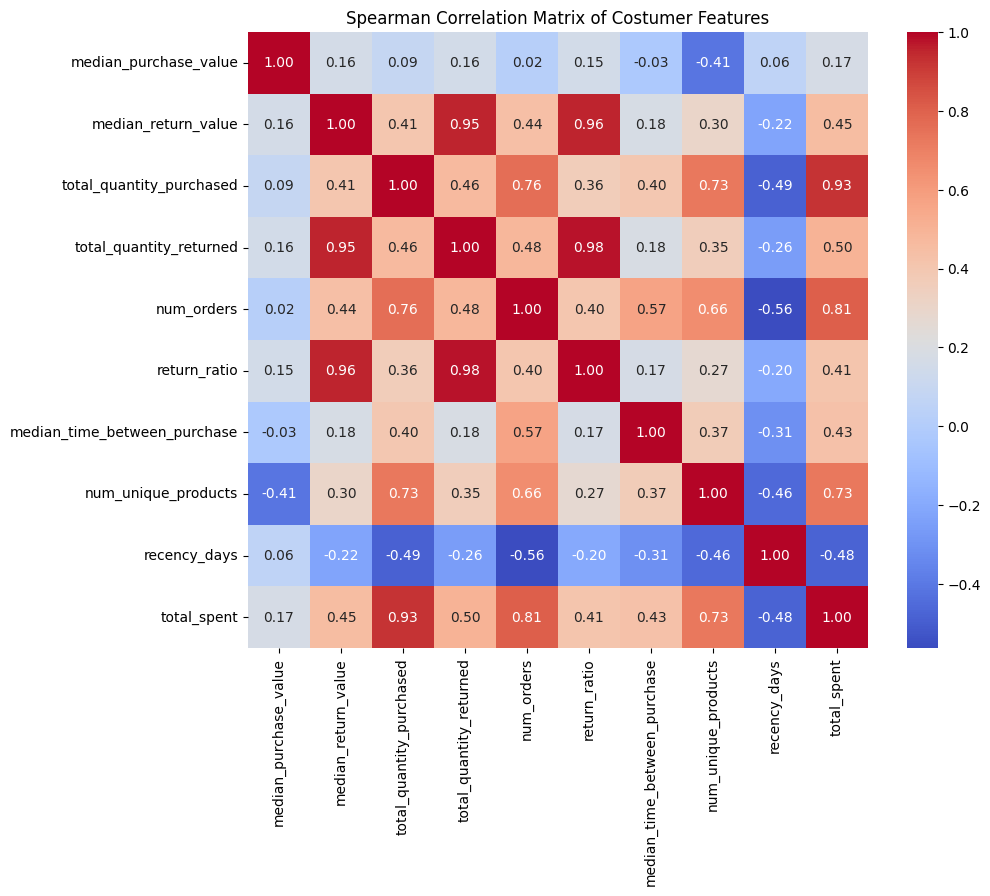

In [27]:
# features for clustering analysis
feature_cols = ['median_purchase_value', 'median_return_value',
       'total_quantity_purchased', 'total_quantity_returned', 'num_orders',
       'return_ratio', 'median_time_between_purchase', 'num_unique_products', 'recency_days', 'total_spent'
]
# Spearman correlation matrix (robust to non-linear relationships)
corr_matrix = df_client[feature_cols].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Spearman Correlation Matrix of Costumer Features")
plt.show()


To identify the most suitable features for clustering, I analyzed the Spearman correlation matrix of all extracted variables. I chose Spearman over Pearson for two reasons: it is robust to outliers  and captures monotonic relationships that are not necessarily linear.

The matrix reveals redundancy among several variables:
**Very high correlations (ρ > 0.80) – to be removed:**
- `total_quantity_purchased` and `total_spent` (ρ = 0.93): essentially the same information. I am keeping `total_spent` as it better reflects economic value.
- `median_return_value` and `total_quantity_returned` (ρ = 0.95): return value and quantity are redundant. I opted to keep only `return_ratio` to summarize return behavior, as it is highly correlated with both (0.96 and 0.98, respectively).
**High correlations:**
- `num_orders` with `total_quantity_purchased` (ρ = 0.76), `total_spent` (ρ = 0.81), and `num_unique_products` (ρ = 0.66): customers who place more orders buy more, spend more, and purchase a wider variety of products. I am excluding `num_orders` because frequency information is already captured by `median_time_between_purchase`.
- `num_unique_products` with `total_quantity_purchased` (ρ = 0.73) and `total_spent` (ρ = 0.73): those who buy more in terms of quantity and value also tend to purchase a greater variety of products. I decided to keep `num_unique_products` as well, because it adds information regarding basket variety. 
**Moderate negative correlations:**
- `recency_days` with `num_orders` (ρ = -0.56), `total_quantity_purchased` (ρ = -0.49), `total_spent` (ρ = -0.48): more recent customers (low recency) tend to have more purchases and higher spending.

### Final Selected Features
Based on the analysis, I selected 5 features that are balanced and have low inter-correlation: `total_spent`, `return_ratio`, `recency_days`, `median_time_between_purchase`, and `num_unique_products`

## Feature Selection and Data Normalization and Transformation for GMM

In [11]:
# Select final feature set for clustering
features_rfm =[
    "total_spent",
    #"num_orders",
    "return_ratio",
    "recency_days",
    "median_time_between_purchase",
    "num_unique_products"

]
# Check skewness of features (indicates need for transformation)
print("Feature skewness before transformation:")
print(df_client[features_rfm].skew())

Feature skewness before transformation:
total_spent                     19.345166
return_ratio                     7.892226
recency_days                     1.241886
median_time_between_purchase     2.214226
num_unique_products              6.933603
dtype: float64


Almost all the features are heavily right-skewed, which isn't great for a Gaussian model like GMM.

First, I apply a RobustScaler at the raw data – mainly because it's based on median and IQR, so it handles outliers way better than StandardScaler would. Then I used MCD to flag and filter out the most extreme customer cases (I will analyze them separately at the end). After that, I applied some transformations to handle the skewness: log1p on total_spent, num_unique_products, and median_time_between_purchase, and a square root on return_ratio. I re-apply RobustScaler in order to have every variable on the same scale.

In [12]:
from sklearn.preprocessing import RobustScaler #less affect by extreme outliers

from sklearn.preprocessing import StandardScaler

scaler = RobustScaler()
#scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_client[features_rfm])

# PCA visualization

Explained variance ratio: [0.73326593 0.24791298]
Total variance explained: 0.9811789065092226


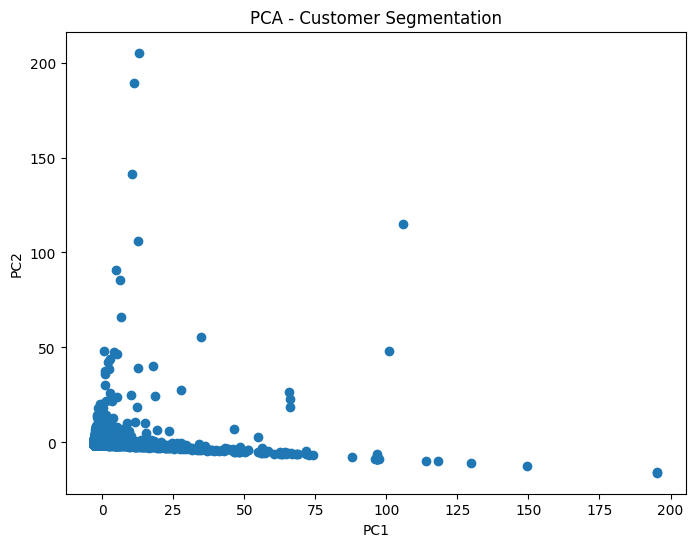

In [13]:
from sklearn.decomposition import PCA #PCA for dimensionality reduction and visualization

pca = PCA(n_components=2)

X_transformed = pca.fit_transform(scaled_data)

# Display explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

# PCA plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_transformed[:, 0],
    X_transformed[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA - Customer Segmentation")

plt.show()

The first two principal components explain 99% of the total variance.
There are some outliers in the plot, which can be identify as isolated points at the edges of the principal component space. These could be misleading for a GMM, which assumes a multivariate normal distribution and is therefore sensitive to extreme values.

## Outliers detection

In [14]:
# Detect outliers using Minimum Covariance Determinant (MCD) - robust covariance estimation
from sklearn.covariance import MinCovDet

mcd = MinCovDet(random_state=42)
mcd.fit(scaled_data)

dist = mcd.mahalanobis(scaled_data) # Mahalanobis distances

threshold = np.percentile(dist, 95)#threshold at 95th percentile

# Identify outliers
outliers = dist > threshold

print("Outliers:", outliers.sum())
print("Outlier percentage:", outliers.mean() * 100)

Outliers: 218
Outlier percentage: 5.014952841039798


## Check Skewness after outliers removal

In [15]:
df_no_outlier = df_client.loc[~outliers].copy()# Remove outliers from the dataset

print("Feature skewness after outlier removal:")
print(df_no_outlier[features_rfm].skew())

Feature skewness after outlier removal:
total_spent                     1.872911
return_ratio                    8.154419
recency_days                    1.187303
median_time_between_purchase    2.149625
num_unique_products             2.100125
dtype: float64



After removing the most extreme cases, I checked how the skewness of each feature had changed. The results were mixed:
- `total_spent` dropped from 19.35 to 1.87
- `num_unique_products` dropped from 6.93 to 2.10
- `recency_days` and `median_time_between_purchase` remained similar to their previous values since they weren't heavily impacted by outliers to begin with.

However, all features still exhibit positive skewness far greater than 1. The `return_ratio` worsened (from 7.89 to 8.15) due to a concentration of values ​​close to zero among the remaining customers. So, while outlier removal helped to some extent, it clearly wasn't enough on its own. The data still needs further transformations to bring the distributions closer to normality before the clustering.


## Transformations to Reduce Skewness

In [16]:
df_clean=df_no_outlier.copy()

# Apply log transformation to highly skewed features to normalize distributions
cols_log = [
    "total_spent",
    #"num_orders",
    "num_unique_products",
    "median_time_between_purchase"
]

for col in cols_log:
    df_clean[col] = np.log1p(df_clean[col])

df_clean["return_ratio"] = np.sqrt(df_clean["return_ratio"])


print("Feature skewness after log transformation:")
print(df_clean[features_rfm].skew())

Feature skewness after log transformation:
total_spent                    -0.187790
return_ratio                    3.519672
recency_days                    1.187303
median_time_between_purchase   -0.370203
num_unique_products            -0.350196
dtype: float64


After removing outliers, I applied `log1p` to `total_spent`, `num_unique_products`, and `median_time_between_purchase`, and `sqrt` to `return_ratio`.

The transformations further reduced skewness for most features. `total_spent`, `median_time_between_purchase`, and `num_unique_products` now exhibit slight negative skewness (around -0.2 to -0.4), indicating approximately symmetrical distributions, while`recency_days` retains a skewness of 1.19, which is acceptable for clustering. `return_ratio`, however, remains highly skewed (3.52) due to the high concentration of zero values ​​(customers with no returns), though the `sqrt` transformation improved the situation compared to the initial skewness of 8.15.

## PCA After Outlier Removal and Transformations

Explained variance ratio after cleaning: [0.60717086 0.25067414]
Total variance explained: 0.8578450053587915


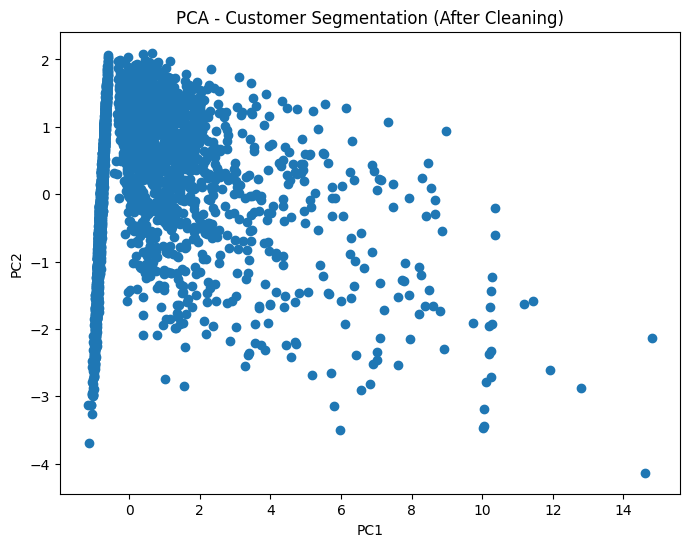

In [17]:
# Prepare data for final clustering

X_clean = df_clean[features_rfm].copy()


scaler_final = RobustScaler()
#scaler_final = StandardScaler()

X_clean_scaled = scaler_final.fit_transform(X_clean)


#PCA for visualization after removing the outliers
pca_clean = PCA(n_components=2)

pca_df_clean = pca_clean.fit_transform(X_clean_scaled)
print("Explained variance ratio after cleaning:", pca_clean.explained_variance_ratio_)
print("Total variance explained:", sum(pca_clean.explained_variance_ratio_))

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df_clean[:, 0],
    pca_df_clean[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA - Customer Segmentation (After Cleaning)")

plt.show()




Compared to the initial PCA analysis (which explained approximately 99% of the variance), the explained variance has decreased to 85%. This reduction is given by the removing of extreme observations that, while contributing significantly to the overall variance, did not represent typical customer behavior.

The data now appear more concentrated in a better-defined and compact area, with less isolated points at the edges.

## Correlation Matrix After Transformations

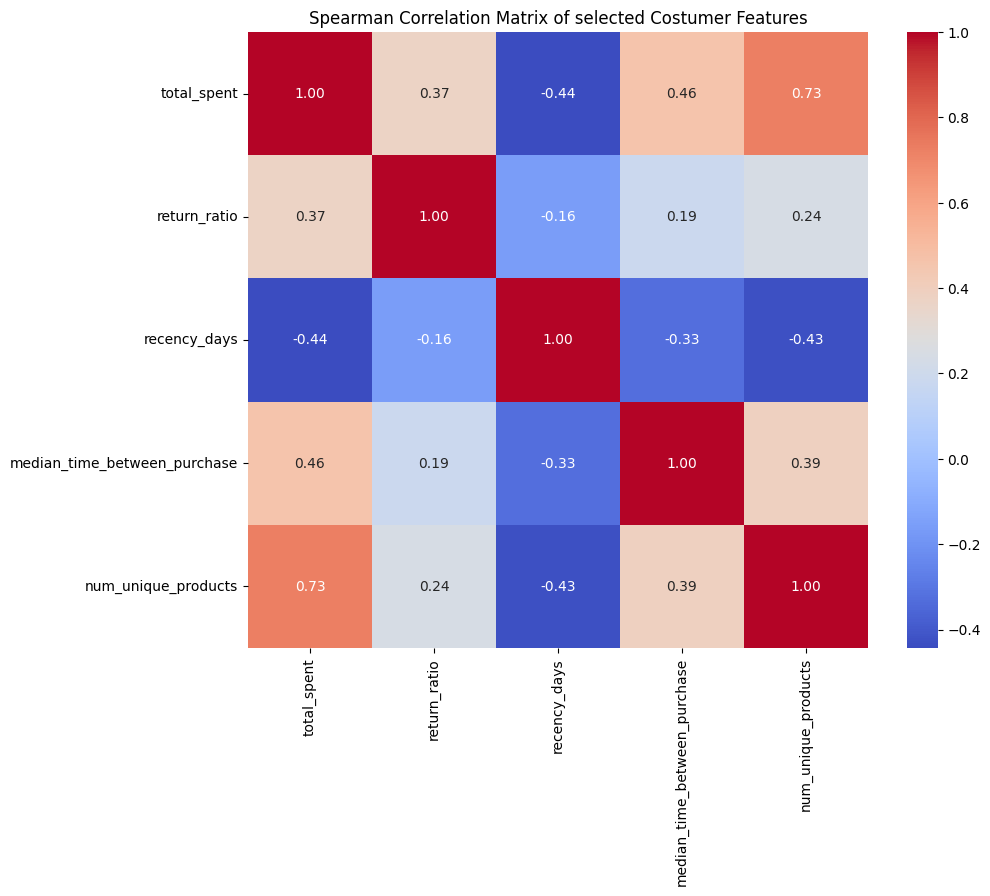

In [31]:
# Recalculate correlation matrix on cleaned data
features_rfm =[
    "total_spent",
    #"num_orders",
    "return_ratio",
    "recency_days",
    "median_time_between_purchase",
    "num_unique_products"
]

corr_matrix = df_clean[features_rfm].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Spearman Correlation Matrix of selected Costumer Features")
plt.show()

All correlations are below 0.75 in absolute value.
The highest correlation (0.73) is observed between `total_spent` and `num_unique_products`, meaning that customers who spend more tend to purchase a wider variety of products. I chose to retain both variables because `num_unique_products` captures a specific behavioral aspect: shopping basket variety. This information is qualitatively distinct from total spending and helps distinguish between customers who spend heavily on a few items and those who purchase many different products, enriching the cluster profiling.
`recency_days` also shows moderate negative correlations with `total_spent` (-0.44) and `num_unique_products` (-0.43), confirming that more recent customers tend to spend more and purchase a greater number of products. `return_ratio` maintains low correlations with all other features (≤ 0.37), so it adds unique information regarding return behavior.

# Why I chose the Gaussian Mixture Model (GMM)

Unlike K-means, GMM provides probabilistic rather than deterministic cluster assignments. Each customer is assigned a probability of belonging to every cluster, making it possible to identify observations located near cluster boundaries.
But in our data, the average assignment confidence turned out to be around 0.94, so we're getting pretty clear results. It also allows to identifying client on the boundary between clusters.
GMM also lets clusters have **elliptical** shapes and varying orientations. That means it can capture correlations between variables way better and actually fit the real structure of the data.

It's based on **maximum likelihood estimation** and the EM algorithm.  I used BIC to figure out the right number of clusters, balancing fit and complexity.

Despite its advantages, GMM has some limitations:
- **Sensitivity to non-normality**: it requires data that follows approximately Gaussian distributions; hence the application of transformations (log and square root) and outlier removal to better approximate the normality assumed by the model.
- **Risk of overfitting**: too many clusters can create non-meaningful segments; using BIC plot helped select a balanced number (9 clusters)


## Selecting the Optimal Number of Clusters Using BIC

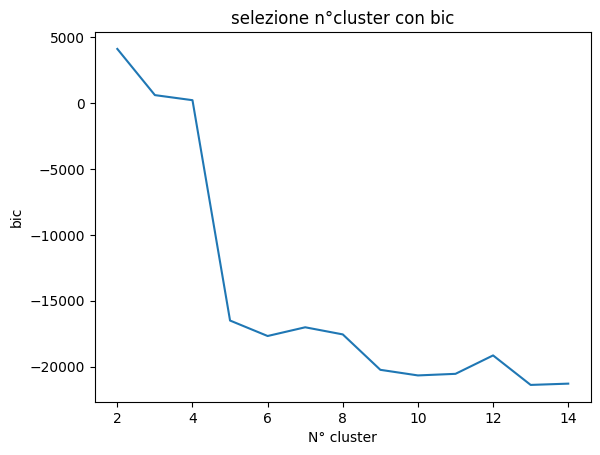

In [19]:
from sklearn.mixture import GaussianMixture

# Bayesian Information Criterion (BIC) to select optimal number of clusters
bic=[]
n_components_range=range(2,15)


for n in n_components_range:
    gmm = GaussianMixture( n_components=n, random_state=42)
    gmm.fit(X_clean_scaled)
    bic.append(gmm.bic(X_clean_scaled))

# Plot BIC values for different cluster numbers
plt.plot(n_components_range, bic)
plt.xlabel("N° cluster")
plt.ylabel("bic")
plt.title("selezione n°cluster con bic")
plt.show()


In [20]:
# Select optimal number of clusters based on minimum BIC
best_n = n_components_range[np.argmin(bic)]
print("Numero ottimale cluster:", best_n)

Numero ottimale cluster: 13



I use the Bayesian Information Criterion (BIC) to determine the optimal number of clusters for the Gaussian Mixture Model. The BIC balances model goodness-of-fit with complexity, penalizing models with an excessive number of parameters.

Although the BIC reaches its minimum value at 13 clusters, I selected 9 clusters because the reduction in BIC beyond this point is modest and a higher number of clusters would risk creating groups that are too small and specific—making them difficult to interpret and of limited use for targeted marketing strategies.

The goal is to obtain customer segments that are sufficiently distinct yet large enough to represent meaningful customer groups for the company.

## Cluster Assignment Evaluation

count    4129.000000
mean        0.941199
std         0.110927
min         0.372112
25%         0.947258
50%         0.993381
75%         0.999957
max         1.000000
dtype: float64


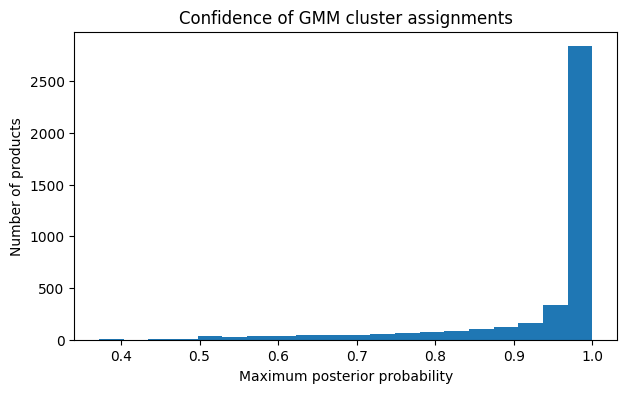

Products with P > 0.99 : 54.7%
Products with P > 0.95 : 74.6%
Products with P > 0.90 : 81.4%
Products with P < 0.70 : 6.5%


In [ ]:
# Fit GMM with optimal number of clusters
gmm = GaussianMixture(
    n_components=9,
    random_state=42
)

labels = gmm.fit_predict(X_clean_scaled)


# Posterior probabilities
probs = gmm.predict_proba(X_clean_scaled)

# Highest probability for each observation
max_probs = probs.max(axis=1)

print(pd.Series(max_probs).describe())

plt.figure(figsize=(7,4))

plt.hist(max_probs, bins=20)

plt.xlabel("Maximum posterior probability")
plt.ylabel("Number of Clients")
plt.title("Confidence of GMM cluster assignments")
plt.show()

print(f"Clients with P > 0.99 : {(max_probs > 0.99).mean()*100:.1f}%")
print(f"Clients with P > 0.95 : {(max_probs > 0.95).mean()*100:.1f}%")
print(f"Clients with P > 0.90 : {(max_probs > 0.90).mean()*100:.1f}%")
print(f"Clients with P < 0.70 : {(max_probs < 0.70).mean()*100:.1f}%")


I analyze the posterior probabilities (the maximum probability of cluster membership for each customer). Values ​​close to 1 indicate that the customer has been assigned to their cluster with high confidence.

Most customers are assigned with high confidence, suggesting that the clusters are reasonably well separated. Indeed, the vast majority of customers (over 80%) are assigned with high confidence (P > 0.90), with a median of 0.99 indicating that half of the customers have near-certainty regarding their cluster membership.

The presence of a small percentage (6.5%) of customers with low confidence (P < 0.70) indicates that these customers are located in boundary areas between different clusters, where the assignment is less distinct.
The histogram shows a distribution heavily skewed toward high values, confirming that most observations are assigned with high confidence.

## Cluster Visualization
## PCA Projection

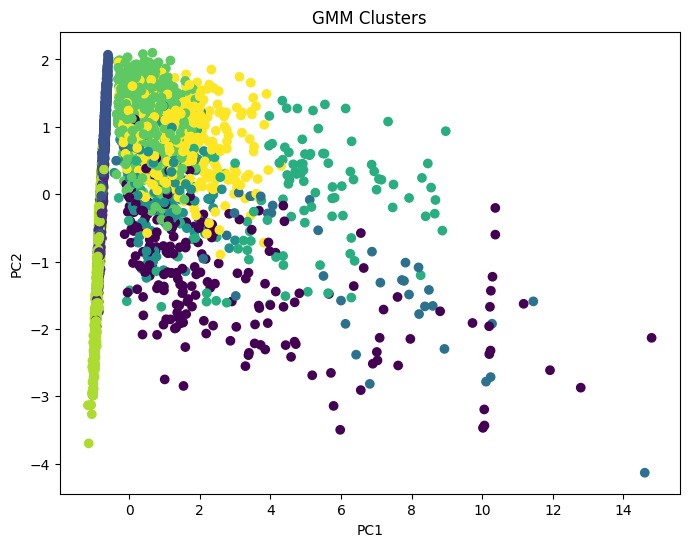

In [22]:
# Visualize clusters with PCA 
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df_clean[:,0],
    pca_df_clean[:,1],
    c=labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("GMM Clusters")

plt.show()

The PCA plot displays the distribution of customers in the two-dimensional space defined by the first two principal components, colored according to the cluster assigned by the GMM.

Areas of overlap between clusters are visible, alongside areas containing elements that belong to a single cluster. Customers in the overlapping zones have less distinct membership probabilities, whereas those in the well-defined zones are assigned with high confidence.


### Distribution Pairplot

Clusters with zero-return customers: [2 7 1]


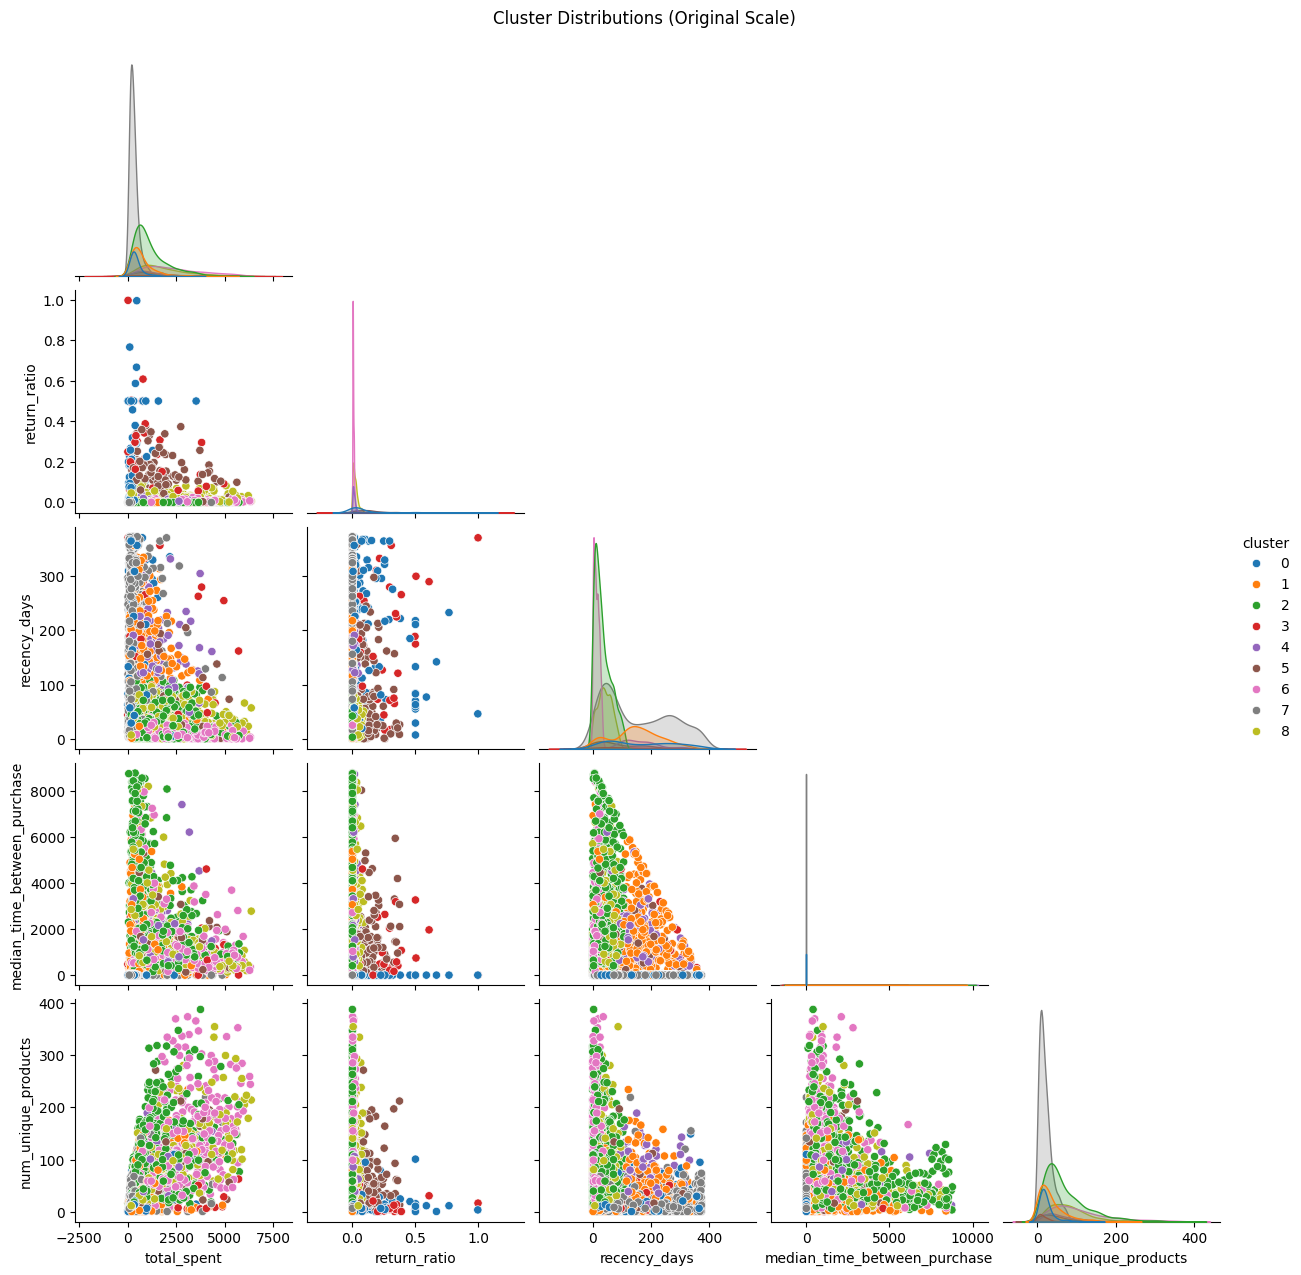

In [ ]:
# Create dataframe with ORIGINAL (back-transformed) values and cluster assignments
# back-transform log-transformed values to original scale
df_backtransformed = df_clean.copy()
for col in ["total_spent", "num_unique_products", "median_time_between_purchase"]:
    df_backtransformed[col] = np.expm1(df_backtransformed[col])

df_backtransformed["return_ratio"]=df_backtransformed["return_ratio"]**2

df_backtransformed["cluster"] = labels

# Check if any cluster consists only of customers with zero returns
print("Clusters with zero-return customers:", 
      df_backtransformed[df_backtransformed["return_ratio"] == 0]["cluster"].unique())

# pairplot with original scale values
sns.pairplot(
    df_backtransformed,
    vars=features_rfm,  # These are now in original scale
    hue="cluster",
    palette="tab10",
    corner=True
)
plt.suptitle("Cluster Distributions (Original Scale)", y=1.02)
plt.show()


cluster_sizes = df_backtransformed.groupby("cluster").size().rename("cluster_size")


### Back-transforming Data to the Original Scale

To interpret the clusters, I converted the variables back to their original scale by applying the inverse transformations:`expm1` (inverse of `log1p`) for `total_spent`, `num_unique_products`, and `median_time_between_purchase`, and squaring for `return_ratio`.
This step is crucial for making the values ​​interpretable in business terms (e.g., spending in euros, number of products, days between purchases).

### Pairplot

The pairplot displays the feature distributions in the original scale for each cluster.
Even though some overlap is visible in the pairplots, it is expected because the pairplot represents only two variables at a time, whereas the GMM is fitted in a five-dimensional feature space.

The presence of clusters consisting solely of customers with no returns (clusters 2, 7, and 1) indicates that the model has identified groups with homogeneous behaviors.

## Cluster Profile Analysis

In [24]:
cluster_sizes = df_backtransformed.groupby("cluster").size().rename("cluster_size")

# median values for all features
cluster_medians = df_backtransformed.groupby("cluster")[features_rfm].median().round(2)

# mean values for all features
clusters_mean= df_backtransformed.groupby("cluster")[features_rfm].mean().round(2)

original_clusters_median = pd.concat([cluster_sizes, cluster_medians], axis=1)

print("\nCluster profiles (median values - original scale):")
print(original_clusters_median)

original_clusters_mean = pd.concat([cluster_sizes, clusters_mean], axis=1)

print("\nCluster profiles (mean values - original scale):")
print(original_clusters_mean)


Cluster profiles (median values - original scale):
         cluster_size  total_spent  return_ratio  recency_days  \
cluster                                                          
0                 213       328.20          0.02         161.0   
1                 418       575.63          0.00         148.0   
2                1039       897.62          0.00          25.0   
3                  45       755.75          0.15         121.0   
4                 130      1025.77          0.01         150.5   
5                 122      1062.23          0.11          63.0   
6                 458      2071.43          0.00          10.5   
7                1305       243.94          0.00         128.0   
8                 399      1580.93          0.02          40.0   

         median_time_between_purchase  num_unique_products  
cluster                                                     
0                                0.00                 17.0  
1                             1074.59 


After identifying the clusters, I characterize them by calculating the number of assigned customers and the median and mean: for each feature.
I present both statistics because the median is more robust against outliers, whereas the mean provides an overall view of the cluster's center.

### Identified Clusters

| Cluster | Size | Spend (median) | Return Rate | Recency (days) | Time Between Purchases (hours) | Unique Products |
|---------|------------|-----------------|------------|------------------|-------------------------|----------------|
| 0 | 213 | €328 | 2% | 161 | 0 | 17 |
| 1 | 418 | €576 | 0% | 148 | 1075 | 25 |
| 2 | 1039 | €898 | 0% | 25 | 1541 | 52 |
| 3 | 45 | €756 | 15% | 121 | 321 | 9 |
| 4 | 130 | €1026 | 1% | 151 | 1522 | 50 |
| 5 | 122 | €1062 | 11% | 63 | 960 | 36 |
| 6 | 458 | €2071 | 0% | 11 | 934 | 87 |
| 7 | 1305 | €244 | 0% | 128 | 0 | 16 |
| 8 | 399 | €1581 | 2% | 40 | 1233 | 73 | ### Cluster Interpretation

These are the result of the profiles:

**Clusters 2 and 6**: 458 and 1,039 customers, respectively, characterized by high spending (€898 and €2,071), very low recency (25 and 11 days), and a high number of unique products (52 and 87). These are the most active and valuable customers. Cluster 6, in particular, represents the "top spenders," with a median expenditure of €2,071.

**Cluster 7**: The largest cluster (1,305 customers), characterized by low spending (€244), average recency (128 days), an inter-purchase time of 0 (indicating customers who made only a single purchase), and few unique products (16). This group represents occasional or "one-shot" customers.

**Clusters 0 and 3**: Clusters with the highest return rates (2% and 15%). Cluster 3, in particular (comprising only 45 customers), shows a 15% return rate and a recency of 121 days, suggesting a group that returns a significant portion of their purchases.

**Clusters 1, 4, 5, and 8**: Intermediate clusters with mixed characteristics, distinguished by increasing spending levels (ranging from €576 to €1,581) and varying combinations of recency and product variety.

## Outlier Analysis

In [25]:
# Analyze outlier characteristics

# Create dataframe with outlier information
df_outliers = df_client[outliers].copy()
df_outliers['mahalanobis_distance'] = dist[outliers]

# 1. Count outliers
print(f"Outliers: {outliers.sum()} out of {len(df_client)} customers ({outliers.mean()*100:.1f}%)")

# 2. Compare outlier characteristics with normal customers
print("\n" + "="*50)
print("OUTLIER COMPARISON (median values)")
print("="*50)

for col in features_rfm:
    normal = df_client.loc[~outliers, col].median()
    outlier_val = df_outliers[col].median()
    
    if outlier_val > normal * 2:
        print(f"{col}: OUTLIER HIGHER ({outlier_val:.1f} vs {normal:.1f})")
    elif outlier_val < normal / 2:
        print(f"{col}: OUTLIER LOWER ({outlier_val:.1f} vs {normal:.1f})")
    else:
        print(f"{col}: similar ({outlier_val:.1f} vs {normal:.1f})")

# %%
# Classify outliers by type
print("\n" + "="*50)
print("OUTLIER TYPES")
print("="*50)

print(f" Customers with spending > 95th percentile: {(df_outliers['total_spent'] > df_client['total_spent'].quantile(0.95)).sum()}")
print(f" Customers with high return ratio (>50%): {(df_outliers['return_ratio'] > 0.5).sum()}")
print(f" Inactive customers (>1 year since last purchase): {(df_outliers['recency_days'] > 365).sum()}")
#print(f" One-time purchasers: {(df_outliers['num_orders'] == 1).sum()}")

Outliers: 218 out of 4347 customers (5.0%)

OUTLIER COMPARISON (median values)
total_spent: OUTLIER HIGHER (9691.5 vs 623.8)
return_ratio: OUTLIER HIGHER (0.0 vs 0.0)
recency_days: OUTLIER LOWER (8.0 vs 53.0)
median_time_between_purchase: similar (356.2 vs 574.4)
num_unique_products: OUTLIER HIGHER (160.5 vs 33.0)

OUTLIER TYPES
 Customers with spending > 95th percentile: 204
 Customers with high return ratio (>50%): 0
 Inactive customers (>1 year since last purchase): 1


## Outlier Analysis

To understand the nature of the customers identified as outliers (approximately 5% of the total), I compare their characteristics with those of normal customers and classify them based on their anomalous behavior. I did that because these customers were excluded only to improve the clustering of typical customer behaviour, but from a business perspective, they represent high-value customers.

### Outlier Characteristics

| Feature | Outliers (median) | Normal (median) | Difference |
|---------|-------------------|-------------------|------------|
| `total_spent` | €9,691.5 | €623.8 | **Extremely higher** (>15x) |
| `return_ratio` | 0% | 0% | Similar |
| `recency_days` | 8 days | 53 days | **Much lower** (more recent customers) |
| `median_time_between_purchase` | 356 hours | 574 hours | Similar |
| `num_unique_products` | 160.5 | 33.0 | **Extremely higher** (>4x) |

## Outlier Profile

Outliers differ from normal customers primarily in three aspects: they spend much more, have much lower recency, and purchase a wider variety of products. 
These outliers are likely to represent large business clients or particularly active customers. – not anomalies to be excluded, but high-value customers with extreme behaviors:
- **204 out of 209 customers (94%)** have spending above the 95th percentile – confirming they are top spenders
- **0 customers** have a return rate above 50% – no significant issues with excessive returns
- **Only 1 customer** has been inactive for over a year – extreme inactivity is not a common outlier trait

